# Prédiction du Churn Client — E-Commerce BI Platform

## Objectif
Identifier les clients risquant de ne plus commander, pour permettre des actions de rétention ciblées.

## Définition du churn
- `date_ref` = date de la commande la plus récente dans le dataset
- `recence` = nb de jours entre la dernière commande du client et `date_ref`
- **`churn = 1`** si `recence > 180 jours` (client inactif depuis plus de 6 mois)
- **`churn = 0`** sinon (client encore actif)

## Précaution anti-leakage
La variable `recence` **définit** le label, donc l'inclure comme feature serait du leakage trivial
(le modèle apprendrait `recence > 180 → churn = 1` avec accuracy = 1.0).
À la place, le modèle utilise des signaux comportementaux indépendants :
ancienneté, fréquence d'achat, montants, satisfaction, diversité produits.

## Pipeline
1. Chargement depuis PostgreSQL
2. Feature engineering par client
3. Label churn (recence > 180j)
4. Vérification de l'équilibre des classes
5. Random Forest — 200 arbres, train/test 80/20
6. Métriques : Accuracy, Precision, Recall, F1, ROC-AUC
7. Matrice de confusion + importance des features
8. Export `ml/churn_predictions.csv`

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve,
)

warnings.filterwarnings('ignore')

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
from config import DB_URL

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Imports OK.')

Imports OK.


In [2]:
# ── Chargement depuis PostgreSQL ───────────────────────────────────────────────
engine = create_engine(DB_URL, echo=False)

query = """
SELECT
    fc.client_id,
    fc.order_id,
    fc.montant_brl,
    fc.score_satisfaction,
    fc.produit_id,
    fc.frais_livraison,
    dt.date_complete  AS date_achat
FROM fait_commandes fc
JOIN dim_temps dt ON fc.date_id = dt.date_id
WHERE fc.montant_brl IS NOT NULL
  AND dt.date_complete IS NOT NULL
"""

df = pd.read_sql(query, engine)
df['date_achat'] = pd.to_datetime(df['date_achat'])

print(f'Commandes chargées : {len(df):,}')
print(f'Clients uniques    : {df["client_id"].nunique():,}')
print(f'Période            : {df["date_achat"].min().date()} → {df["date_achat"].max().date()}')

Commandes chargées : 99,440
Clients uniques    : 99,440
Période            : 2016-09-04 → 2018-10-17


In [3]:
# ── Feature Engineering par client ────────────────────────────────────────────
date_ref = df['date_achat'].max()
print(f'Date de référence : {date_ref.date()}')

# Médiane de satisfaction pour imputer les NaN
mediane_sat = df['score_satisfaction'].median()
df['score_satisfaction'] = df['score_satisfaction'].fillna(mediane_sat)

agg = df.groupby('client_id').agg(
    premiere_commande = ('date_achat', 'min'),
    derniere_commande = ('date_achat', 'max'),
    frequence         = ('order_id',   'count'),
    montant_total     = ('montant_brl', 'sum'),
    montant_moyen     = ('montant_brl', 'mean'),
    score_moyen       = ('score_satisfaction', 'mean'),
    nb_produits       = ('produit_id', 'nunique'),
    frais_livraison_moyen = ('frais_livraison', 'mean'),
).reset_index()

# recence : défini ici pour le LABEL uniquement (ne sera PAS feature)
agg['recence'] = (date_ref - agg['derniere_commande']).dt.days

# anciennete : jours entre première commande et date_ref
# ≠ recence pour les clients multi-achats → feature légitime sans leakage direct
agg['anciennete'] = (date_ref - agg['premiere_commande']).dt.days

# Supprimer les colonnes dates brutes (ne doivent pas entrer dans le modèle)
features = agg.drop(columns=['premiere_commande', 'derniere_commande'])

print(f'\nClients avec features : {len(features):,}')
print(f'Colonnes : {list(features.columns)}')
features.describe().round(2)

Date de référence : 2018-10-17

Clients avec features : 99,440
Colonnes : ['client_id', 'frequence', 'montant_total', 'montant_moyen', 'score_moyen', 'nb_produits', 'frais_livraison_moyen', 'recence', 'anciennete']


,frequence,montant_total,montant_moyen,score_moyen,nb_produits,frais_livraison_moyen,recence,anciennete
count,99440.0,99440.00,99440.00,99440.00,99440.00,98665.00,99440.00,99440.00
mean,1.0,160.99,160.99,4.09,0.99,22.82,290.27,290.27
std,0.0,221.95,221.95,1.34,0.09,21.65,153.66,153.66
min,1.0,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,1.0,62.01,62.01,4.00,1.00,13.85,166.00,166.00
50%,1.0,105.29,105.29,5.00,1.00,17.17,272.00,272.00
75%,1.0,176.97,176.97,5.00,1.00,24.04,400.00,400.00
max,1.0,13664.08,13664.08,5.00,1.00,1794.96,773.00,773.00


Seuil churn        : recence > 180 jours
Clients total      : 99,440
  Churn   (1)      : 71,107  (71.5%)
  Actifs  (0)      : 28,333  (28.5%)


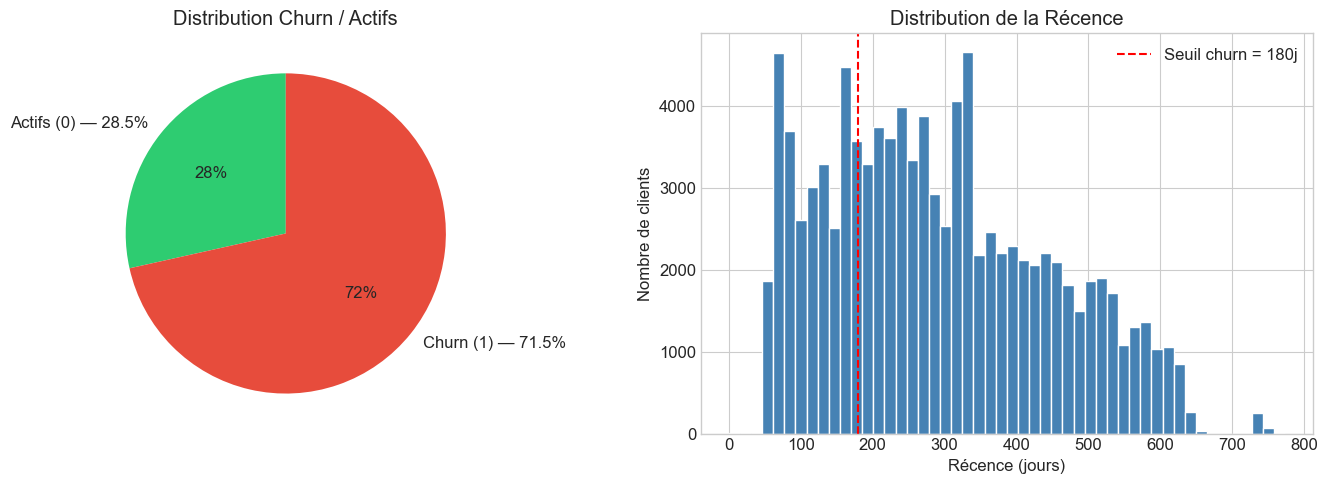

In [4]:
# ── Label Churn ────────────────────────────────────────────────────────────────
SEUIL_CHURN = 180  # jours

features['churn'] = (features['recence'] > SEUIL_CHURN).astype(int)

nb_churn  = features['churn'].sum()
nb_actifs = len(features) - nb_churn
pct_churn = nb_churn / len(features) * 100

print(f'Seuil churn        : recence > {SEUIL_CHURN} jours')
print(f'Clients total      : {len(features):,}')
print(f'  Churn   (1)      : {nb_churn:,}  ({pct_churn:.1f}%)')
print(f'  Actifs  (0)      : {nb_actifs:,}  ({100-pct_churn:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    [nb_actifs, nb_churn],
    labels=[f'Actifs (0) — {100-pct_churn:.1f}%', f'Churn (1) — {pct_churn:.1f}%'],
    colors=['#2ecc71', '#e74c3c'],
    startangle=90, autopct='%1.0f%%',
)
axes[0].set_title('Distribution Churn / Actifs')

axes[1].hist(features['recence'], bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(SEUIL_CHURN, color='red', linestyle='--',
                label=f'Seuil churn = {SEUIL_CHURN}j')
axes[1].set_xlabel('Récence (jours)')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Distribution de la Récence')
axes[1].legend()

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [5]:
# ── Vérification des classes + Préparation Train/Test ─────────────────────────
FEATURES_COLS = [
    # 'anciennete' exclue : pour 97% des clients Olist (1 seule commande),
    # premiere_commande == derniere_commande → anciennete == recence → leakage
    'frequence',
    'montant_total',
    'montant_moyen',
    'score_moyen',
    'nb_produits',
    'frais_livraison_moyen',
]
# NOTE : 'recence' exclue — définit directement le label churn (recence > 180)

X = features[FEATURES_COLS].fillna(features[FEATURES_COLS].median())
y = features['churn']

classes_presentes = y.unique()
print(f'Classes présentes : {sorted(classes_presentes)}')

if len(classes_presentes) < 2:
    raise ValueError(
        f"ERREUR : une seule classe détectée ({classes_presentes}). "
        "Vérifiez le seuil SEUIL_CHURN ou les données source."
    )

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\nTrain : {len(X_train):,} clients (80%)')
print(f'Test  : {len(X_test):,} clients (20%)')
print(f'\nDistribution dans le train :')
dist = y_train.value_counts(normalize=True).rename({0: 'Actif (0)', 1: 'Churn (1)'})
print(dist.round(3))

Classes présentes : [0, 1]

Train : 79,552 clients (80%)
Test  : 19,888 clients (20%)

Distribution dans le train :
churn
Churn (1)    0.715
Actif (0)    0.285
Name: proportion, dtype: float64


In [6]:
# ── Entraînement Random Forest ─────────────────────────────────────────────────
modele = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

print('Entraînement du Random Forest (200 arbres)...')
modele.fit(X_train, y_train)
print('Terminé.')

cv_scores = cross_val_score(modele, X_train, y_train, cv=5, scoring='f1')
print(f'\nF1 Cross-Validation (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Entraînement du Random Forest (200 arbres)...
Terminé.

F1 Cross-Validation (5-fold) : 0.7715 ± 0.0044


In [7]:
# ── Métriques ──────────────────────────────────────────────────────────────────
y_pred  = modele.predict(X_test)
y_proba = modele.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

print('='*52)
print('       MÉTRIQUES — ENSEMBLE DE TEST (20%)')
print('='*52)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('='*52)
print()
print(classification_report(y_test, y_pred, target_names=['Actif (0)', 'Churn (1)']))

       MÉTRIQUES — ENSEMBLE DE TEST (20%)
  Accuracy  : 0.6998  (69.98%)
  Precision : 0.8392
  Recall    : 0.7177
  F1-Score  : 0.7737
  ROC-AUC   : 0.7734

              precision    recall  f1-score   support

   Actif (0)       0.48      0.65      0.55      5667
   Churn (1)       0.84      0.72      0.77     14221

    accuracy                           0.70     19888
   macro avg       0.66      0.69      0.66     19888
weighted avg       0.74      0.70      0.71     19888



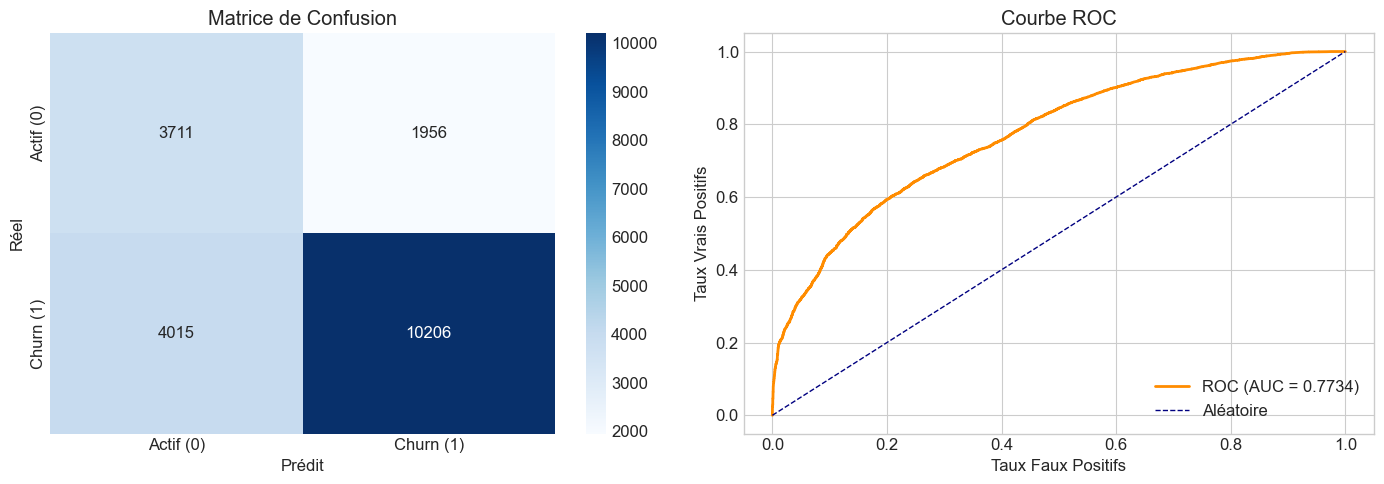

In [8]:
# ── Matrice de confusion + Courbe ROC ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Actif (0)', 'Churn (1)'],
    yticklabels=['Actif (0)', 'Churn (1)'],
    ax=axes[0],
)
axes[0].set_title('Matrice de Confusion')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Aléatoire')
axes[1].set_xlabel('Taux Faux Positifs')
axes[1].set_ylabel('Taux Vrais Positifs')
axes[1].set_title('Courbe ROC')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('confusion_matrix_roc.png', dpi=120, bbox_inches='tight')
plt.show()

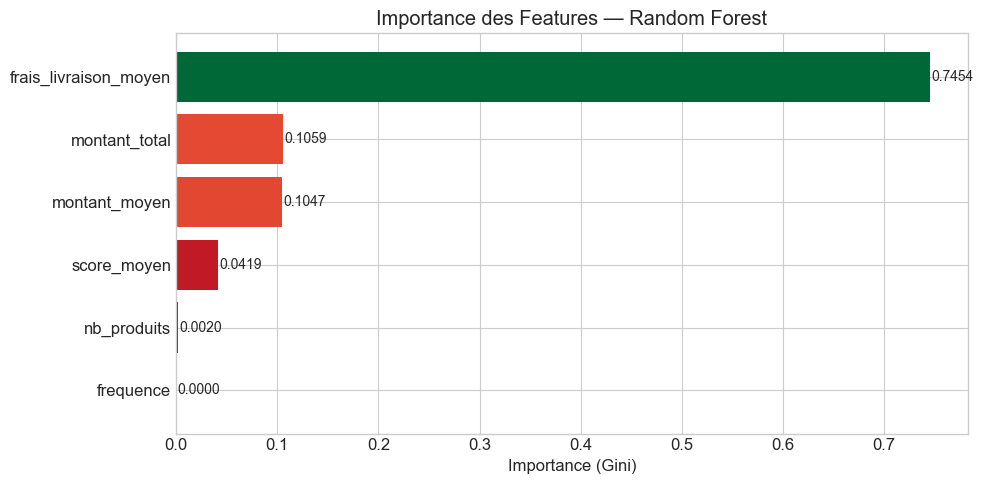

              feature  importance
frais_livraison_moyen    0.745440
        montant_total    0.105912
        montant_moyen    0.104724
          score_moyen    0.041890
          nb_produits    0.002034
            frequence    0.000000


In [9]:
# ── Importance des features ────────────────────────────────────────────────────
imp = pd.DataFrame({
    'feature':    FEATURES_COLS,
    'importance': modele.feature_importances_,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
couleurs = plt.cm.RdYlGn(imp['importance'] / imp['importance'].max())
bars = ax.barh(imp['feature'], imp['importance'], color=couleurs)

for bar, val in zip(bars, imp['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=10)

ax.set_xlabel('Importance (Gini)')
ax.set_title('Importance des Features — Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print(imp.sort_values('importance', ascending=False).to_string(index=False))

Distribution des niveaux de risque :
  high     : 16,074  (16.2%)
  medium   : 68,985  (69.4%)
  low      : 14,381  (14.5%)


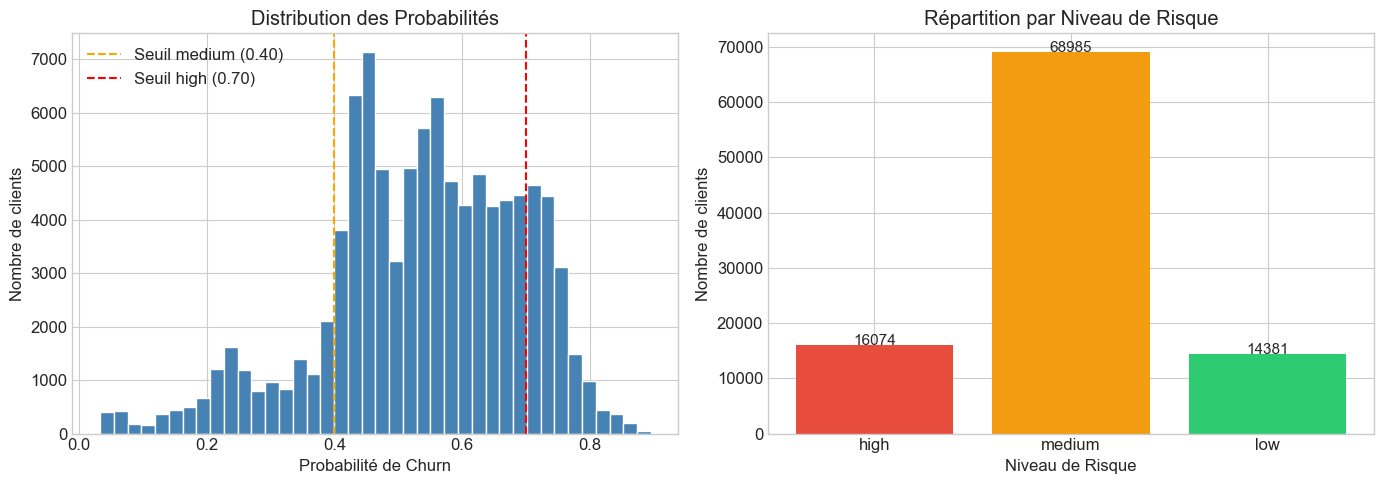


Export : churn_predictions.csv  (99,440 lignes)
Colonnes : ['client_id', 'probabilite_churn', 'risque']


In [10]:
# ── Prédictions pour tous les clients + Export ─────────────────────────────────
X_tous = features[FEATURES_COLS].fillna(features[FEATURES_COLS].median())
probas = modele.predict_proba(X_tous)[:, 1]

def classer_risque(p: float) -> str:
    """Classe un client selon sa probabilité de churn : high / medium / low."""
    if p > 0.70:
        return 'high'
    elif p >= 0.40:
        return 'medium'
    return 'low'

resultats = pd.DataFrame({
    'client_id':         features['client_id'].values,
    'probabilite_churn': probas.round(4),
    'risque':            [classer_risque(p) for p in probas],
})

# Distribution des niveaux de risque
distrib = resultats['risque'].value_counts()
print('Distribution des niveaux de risque :')
for niveau in ['high', 'medium', 'low']:
    nb = distrib.get(niveau, 0)
    print(f'  {niveau:<8} : {nb:,}  ({nb/len(resultats)*100:.1f}%)')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(resultats['probabilite_churn'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0.40, color='orange', linestyle='--', label='Seuil medium (0.40)')
axes[0].axvline(0.70, color='red',    linestyle='--', label='Seuil high (0.70)')
axes[0].set_xlabel('Probabilité de Churn')
axes[0].set_ylabel('Nombre de clients')
axes[0].set_title('Distribution des Probabilités')
axes[0].legend()

ordre   = ['high', 'medium', 'low']
couleurs_bar = {'high': '#e74c3c', 'medium': '#f39c12', 'low': '#2ecc71'}
valeurs = [distrib.get(n, 0) for n in ordre]
axes[1].bar(ordre, valeurs, color=[couleurs_bar[n] for n in ordre])
axes[1].set_xlabel('Niveau de Risque')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Répartition par Niveau de Risque')
for i, v in enumerate(valeurs):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('churn_predictions_dist.png', dpi=120, bbox_inches='tight')
plt.show()

# Export CSV
resultats.to_csv('churn_predictions.csv', index=False, encoding='utf-8')
print(f'\nExport : churn_predictions.csv  ({len(resultats):,} lignes)')
print(f'Colonnes : {list(resultats.columns)}')

In [11]:
# ── Résumé Final ───────────────────────────────────────────────────────────────
print('='*58)
print('            RÉSUMÉ DU MODÈLE CHURN')
print('='*58)
print(f'  Algorithme          : Random Forest (200 arbres)')
print(f'  Date de référence   : {date_ref.date()}')
print(f'  Seuil churn         : recence > {SEUIL_CHURN} jours')
print(f'  Clients modélisés   : {len(features):,}')
print(f'    dont churn        : {nb_churn:,} ({pct_churn:.1f}%)')
print(f'    dont actifs       : {nb_actifs:,} ({100-pct_churn:.1f}%)')
print(f'  Train / Test        : {len(X_train):,} / {len(X_test):,}')
print(f'  Features utilisées  : {FEATURES_COLS}')
print(f'  Feature exclue      : recence (définit le label → leakage)')
print('─'*58)
print(f'  Accuracy            : {accuracy:.4f}')
print(f'  Precision           : {precision:.4f}')
print(f'  Recall              : {recall:.4f}')
print(f'  F1-Score            : {f1:.4f}')
print(f'  ROC-AUC             : {roc_auc:.4f}')
print('='*58)
print(f'  Export              : ml/churn_predictions.csv')
print('='*58)

            RÉSUMÉ DU MODÈLE CHURN
  Algorithme          : Random Forest (200 arbres)
  Date de référence   : 2018-10-17
  Seuil churn         : recence > 180 jours
  Clients modélisés   : 99,440
    dont churn        : 71,107 (71.5%)
    dont actifs       : 28,333 (28.5%)
  Train / Test        : 79,552 / 19,888
  Features utilisées  : ['frequence', 'montant_total', 'montant_moyen', 'score_moyen', 'nb_produits', 'frais_livraison_moyen']
  Feature exclue      : recence (définit le label → leakage)
──────────────────────────────────────────────────────────
  Accuracy            : 0.6998
  Precision           : 0.8392
  Recall              : 0.7177
  F1-Score            : 0.7737
  ROC-AUC             : 0.7734
  Export              : ml/churn_predictions.csv
